   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        2  
2        2  
3        2  
4   

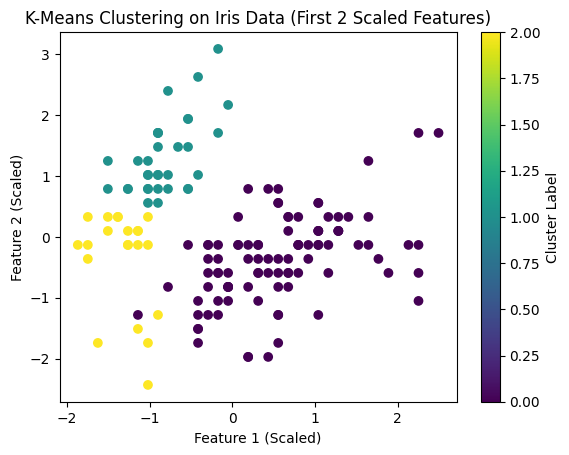

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()

# Create a DataFrame using iris.data
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Display first 5 rows
print(df.head())

# Select features from the DataFrame
X = df.iloc[:, :] # Select all features

# Standardize the data
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Create a KMeans model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')


# Train the KMeans model
kmeans.fit(X_scaled)

# Get cluster labels
clusters = kmeans.predict(X_scaled)


# Add clusters to DataFrame
df['Cluster'] = clusters

print(df.head())

# Visualize clusters
# For visualization, we often use only two principal components or two selected features
# Let's visualize using the first two features after scaling
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.title('K-Means Clustering on Iris Data (First 2 Scaled Features)')
plt.colorbar(label='Cluster Label')
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# Standardize features
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)  # FIX 1: Use transform, not fit_transform, on test data

# Train model
lr = LogisticRegression(C=100.0, random_state=1)
lr.fit(X_train_std, y_train)  # FIX 2: Use .fit() method for training

# Make predictions
y_pred = lr.predict(X_test_std)

# Calculate accuracy
accuracy = np.mean(y_pred == y_test)  # FIX 3: Correct comparison and use np.mean

# Get prediction probabilities
proba = lr.predict_proba(X_test_std)
predicted_classes = proba.argmax(axis=1)  # FIX 4: Use axis=1 to get class with highest probability for each sample

print(f"Accuracy: {accuracy:.3f}")
print(f"Predicted classes for first 5 test samples: {predicted_classes[:5]}")
print(f"True classes for first 5 test samples: {y_test[:5]}")

Accuracy: 1.000
Predicted classes for first 5 test samples: [2 0 0 2 1]
True classes for first 5 test samples: [2 0 0 2 1]


In [ ]:
predicted_classes = proba.argmax(axis=0)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data=pd.read_csv("/content/employee_dataset_150.csv")

In [ ]:
data.head()

,Age,Salary,Department,Experience,Performance
0,50.0,74766.0,HR,Junior,Average
1,NaN,47994.0,Finance,Junior,Excellent
2,29.0,68021.0,Finance,Junior,Good
3,42.0,70303.0,IT,Junior,Average
4,40.0,90647.0,Finance,Senior,Average


In [ ]:
#Identify and display the number of missing values in each column
missing_numbers= data.isnull().sum()
print(missing_numbers)  # Corrected to display the Series

Age            10
Salary         10
Department      0
Experience      8
Performance     0
dtype: int64


In [ ]:
# Calculate the percentage of missing values for each column
percentages= (data.isnull().sum() / len(data)) * 100
print(percentages)  # Corrected to display the Series

Age            6.666667
Salary         6.666667
Department     0.000000
Experience     5.333333
Performance    0.000000
dtype: float64


### Imputing Missing Values

Now, let's fill the missing values in the dataset. We'll use:

*   **Mean imputation** for numerical columns like 'Age' and 'Salary'.
*   **Mode imputation** for the categorical 'Experience' column, as it's common to fill with the most frequent value.

In [ ]:
# Impute missing values for 'Age' with the mean
data['Age'].fillna(data['Age'].mean(), inplace=True)

# Impute missing values for 'Salary' with the mean
data['Salary'].fillna(data['Salary'].mean(), inplace=True)

# Impute missing values for 'Experience' with the most frequent value (mode)
# .mode()[0] is used because .mode() can return multiple values if there's a tie
data['Experience'].fillna(data['Experience'].mode()[0], inplace=True)

print("Dataset after missing value imputation:")
display(data.head())

# Verify that there are no more missing values
print("\nMissing values after imputation:")
print(data.isnull().sum())

Dataset after missing value imputation:


/tmp/ipykernel_1879/3910872236.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
/tmp/ipykernel_1879/3910872236.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

,Age,Salary,Department,Experience,Performance
0,50.000000,74766.0,HR,Junior,Average
1,40.485714,47994.0,Finance,Junior,Excellent
2,29.000000,68021.0,Finance,Junior,Good
3,42.000000,70303.0,IT,Junior,Average
4,40.000000,90647.0,Finance,Senior,Average



Missing values after imputation:
Age            0
Salary         0
Department     0
Experience     0
Performance    0
dtype: int64


### Encoding Categorical Variables

Now we'll convert categorical features into a numerical format suitable for machine learning models:

*   **Experience**: Ordinal mapping (`Junior` -> 0, `Mid` -> 1, `Senior` -> 2)
*   **Department**: One-hot encoding (creates new binary columns for each department category)
*   **Performance**: Label encoding (for the target variable)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Ordinal encoding for 'Experience'
experience_mapping = {'Junior': 0, 'Mid': 1, 'Senior': 2}
data['Experience'] = data['Experience'].map(experience_mapping)

# One-hot encoding for 'Department'
data = pd.get_dummies(data, columns=['Department'], drop_first=True, dtype=int)

# Label encoding for 'Performance' (target variable)
le = LabelEncoder()
data['Performance'] = le.fit_transform(data['Performance'])

print("Dataset after categorical encoding:")
display(data.head())

print("\nUnique values of encoded 'Performance' (target variable):")
print(data['Performance'].unique())

Dataset after categorical encoding:


,Age,Salary,Experience,Performance,Department_HR,Department_IT
0,50.000000,74766.0,0,0,1,0
1,40.485714,47994.0,0,1,0,0
2,29.000000,68021.0,0,2,0,0
3,42.000000,70303.0,0,0,0,1
4,40.000000,90647.0,2,0,0,0



Unique values of encoded 'Performance' (target variable):
[0 1 2]


### Creating a Preprocessing Pipeline Function

To make our preprocessing steps reusable and robust, we'll encapsulate them into a single function. This function will take a raw DataFrame, handle missing values, encode categorical variables, perform a train-test split, and scale features. Critically, it will ensure that transformations (like fitting scalers or encoders) are learned *only* from the training data to prevent data leakage.

The steps within the function will be:
1.  **Copy Data**: Work on a copy to avoid modifying the original DataFrame.
2.  **Ordinal Encode 'Experience'**: Map 'Junior', 'Mid', 'Senior' to 0, 1, 2.
3.  **Impute Missing 'Experience'**: Fill any remaining NaNs (from original data) with the mode.
4.  **Label Encode 'Performance'**: Convert the target variable into numerical labels.
5.  **Separate Features and Target**.
6.  **Train-Test Split**: Divide the data into training and testing sets.
7.  **Impute Numerical Features ('Age', 'Salary')**: Calculate means from the *training set* and apply to both training and test sets.
8.  **One-Hot Encode 'Department'**: Use `ColumnTransformer` and `OneHotEncoder` to apply this only to the 'Department' column, learned from the training set.
9.  **Feature Scaling**: Standardize all numerical features using `StandardScaler`, fitted on the *training set* and applied to both.
10. **Return** the preprocessed training and testing features, and the target variables.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd # Ensure pandas is available for df.copy()

def preprocess_data(raw_df, test_size=0.3, random_state=42):
    df_copy = raw_df.copy()

    # 1. Label encode 'Performance' (target variable) first on the full dataset
    # This assumes 'Performance' is the target and will be dropped from features later
    le = LabelEncoder()
    df_copy['Performance_encoded'] = le.fit_transform(df_copy['Performance'])

    # Separate features (X) and target (y)
    # Drop original 'Performance' and the newly created 'Performance_encoded' to prevent issues
    X = df_copy.drop(['Performance', 'Performance_encoded'], axis=1)
    y = df_copy['Performance_encoded']

    # 2. Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Define column types for preprocessing pipelines
    numerical_features = ['Age', 'Salary']
    categorical_ohe_features = ['Department']
    categorical_ordinal_features = ['Experience']

    # Create preprocessing pipelines
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')), # Impute with mean from train
        ('scaler', StandardScaler()) # Scale with scaler from train
    ])

    categorical_ohe_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')), # Impute for Department if needed
        ('onehot', OneHotEncoder(handle_unknown='ignore')) # One-hot encode from train
    ])

    # For 'Experience', we first impute (most frequent string), then ordinal encode
    # The order of categories for OrdinalEncoder must match the desired mapping {Junior: 0, Mid: 1, Senior: 2}
    ordinal_experience_categories = ['Junior', 'Mid', 'Senior']

    categorical_ordinal_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')), # Impute NaNs in string 'Experience'
        ('ordinal', OrdinalEncoder(categories=[ordinal_experience_categories],
                                   handle_unknown='use_encoded_value', unknown_value=-1)) # use_encoded_value and unknown_value to handle potential unseen categories gracefully
    ])

    # Create a column transformer to apply different transformations to different columns
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat_ohe', categorical_ohe_transformer, categorical_ohe_features),
            ('cat_ord', categorical_ordinal_transformer, categorical_ordinal_features)
        ],
        remainder='drop'
    )

    # Fit and transform the training data, then transform the test data
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    # Return preprocessed features and target variables as numpy arrays
    return X_train_processed, X_test_processed, y_train.to_numpy(), y_test.to_numpy()

)
original_raw_data = pd.read_csv("/content/employee_dataset_150.csv")

print("Running preprocessing pipeline...")
X_train_final, X_test_final, y_train_final, y_test_final = preprocess_data(original_raw_data)

print("\nShape of X_train_final:", X_train_final.shape)
print("Shape of X_test_final:", X_test_final.shape)
print("Shape of y_train_final:", y_train_final.shape)
print("Shape of y_test_final:", y_test_final.shape)

print("\nFirst 5 rows of X_train_final (preprocessed features):\n", X_train_final[:5])
print("\nFirst 5 values of y_train_final (encoded target):\n", y_train_final[:5])

Running preprocessing pipeline...

Shape of X_train_final: (105, 6)
Shape of X_test_final: (45, 6)
Shape of y_train_final: (105,)
Shape of y_test_final: (45,)

First 5 rows of X_train_final (preprocessed features):
 [[-1.57396982  0.35648473  0.          1.          0.          1.        ]
 [ 0.70080591  1.64028675  1.          0.          0.          1.        ]
 [-1.22400433 -0.3782402   0.          0.          1.          2.        ]
 [-0.17410783 -1.30641648  0.          0.          1.          0.        ]
 [-0.78654746  0.          0.          0.          1.          0.        ]]

First 5 values of y_train_final (encoded target):
 [1 0 2 0 0]


### K-Fold Cross-Validation

Now, let's perform K-Fold Cross-Validation using the preprocessed training data (`X_train_final`, `y_train_final`) and a Logistic Regression model.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np



model = LogisticRegression(random_state=42, solver='liblinear')

# Perform K-Fold Cross-Validation
k_folds = 5
scores = cross_val_score(model, X_train_final, y_train_final, cv=k_folds, scoring='accuracy')

# Display the accuracy scores for each fold
print(f"Accuracy scores for each of the {k_folds} folds: {scores}")

# Compute and report mean accuracy and standard deviation
mean_accuracy = np.mean(scores)
std_dev_accuracy = np.std(scores)

print(f"\nMean accuracy: {mean_accuracy:.3f}")
print(f"Standard deviation of accuracy: {std_dev_accuracy:.3f}")

Accuracy scores for each of the 5 folds: [0.38095238 0.38095238 0.38095238 0.47619048 0.47619048]

Mean accuracy: 0.419
Standard deviation of accuracy: 0.047


### Interpretation of Results

*   **Accuracy scores for each fold**: These values show the model's performance on the test set of each fold. Ideally, these scores should be consistent, indicating the model generalizes well across different subsets of the data.
*   **Mean accuracy**: This is the average accuracy across all folds. It provides a more robust estimate of the model's performance than a single train-test split, as it reduces the variance associated with the particular choice of training and testing data.
*   **Standard deviation of accuracy**: This measures the variability of the accuracy scores across the folds. A low standard deviation suggests that the model's performance is stable and not highly dependent on the specific data split. A high standard deviation might indicate that the model is sensitive to the training data and may not generalize consistently.

### Reusable K-Fold Cross-Validation Script

Below is a reusable Python function, `run_cross_validation`, designed to perform K-Fold Cross-Validation. It can work with different datasets (Iris, Wine, and our preprocessed Employee dataset) and various classification models (Logistic Regression, SVM, KNN). The function handles data loading, preprocessing (including scaling), model initialization, and reports the cross-validation accuracy, mean, and standard deviation.

**Key features:**
*   **Dataset Choice:** Select from 'iris', 'wine', or 'employee'.
*   **Model Type:** Choose 'LogisticRegression', 'SVM', or 'KNN'.
*   **K-Folds:** Specify the number of folds for cross-validation.
*   **Data Leakage Prevention:** For 'iris' and 'wine' datasets, `StandardScaler` is applied within a `Pipeline` to ensure scaling is fit only on training folds. The 'employee' dataset utilizes the `preprocess_data` function, which already handles robust preprocessing (including scaling) on the training split.
*   **Formatted Report:** Outputs a clear summary of the results.

In [ ]:
import argparse
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine, load_iris
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline # Import Pipeline

# The preprocess_data function from previous steps is assumed to be available in the notebook's scope.

def run_cross_validation(dataset_choice, model_type, k_folds):
    X = None
    y = None
    initial_model = None

    # 1. Load Data
    print(f"Loading '{dataset_choice}' dataset...")
    if dataset_choice == "iris":
        data = load_iris()
        X = data.data
        y = data.target
    elif dataset_choice == "wine":
        data = load_wine()
        X = data.data
        y = data.target
    elif dataset_choice == "employee":
        # Reload raw data to ensure the function starts with a clean DataFrame
        raw_df = pd.read_csv("/content/employee_dataset_150.csv")
        # preprocess_data returns X_train_final and y_train_final which are already processed (scaled, encoded etc.)
        # We use the training portion for cross-validation
        X, _, y, _ = preprocess_data(raw_df) # Assuming preprocess_data is defined and returns the processed data
    else:
        raise ValueError(f"Unknown dataset choice: {dataset_choice}. Choose from 'wine', 'iris', 'employee'.")

    # 2. Initialize Model
    print(f"Initializing {model_type} model...")
    if model_type == "LogisticRegression":
        initial_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000) # Increased max_iter for convergence
    elif model_type == "SVM":
        initial_model = SVC(random_state=42, gamma='auto') # 'gamma' auto is often a good default
    elif model_type == "KNN":
        initial_model = KNeighborsClassifier()
    else:
        raise ValueError(f"Unknown model type: {model_type}. Choose from 'LogisticRegression', 'SVM', 'KNN'.")

    # 3. Create a Pipeline if needed (for iris and wine, where X is not yet scaled within this function)
    # For 'employee' dataset, X is already preprocessed including scaling by preprocess_data.
    if dataset_choice in ["iris", "wine"]:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', initial_model)
        ])
    else: # For 'employee' dataset, X is already preprocessed and scaled
        pipeline = initial_model # Use the model directly as X is ready

    # 4. Perform K-Fold Cross-Validation
    print(f"Performing {k_folds}-fold cross-validation...")
    scores = cross_val_score(pipeline, X, y, cv=k_folds, scoring='accuracy')

    # 5. Format and report results
    mean_accuracy = np.mean(scores)
    std_dev_accuracy = np.std(scores)

    report = f"\n-- K-Fold Cross-Validation Report --\n"
    report += f"Dataset: {dataset_choice}\n"
    report += f"Model: {model_type}\n"
    report += f"Number of Folds (k): {k_folds}\n"
    report += f"Accuracy scores for each fold: {scores}\n"
    report += f"Mean accuracy: {mean_accuracy:.3f}\n"
    report += f"Standard deviation of accuracy: {std_dev_accuracy:.3f}\n"
    report += f"------------------------------------\n"

    return report

.
if __name__ == '__main__':
    parser = argparse.ArgumentParser(description="Perform K-Fold Cross-Validation.")
    parser.add_argument("--dataset", type=str, required=True,
                        choices=["wine", "iris", "employee"],
                        help="Choice of dataset (wine, iris, employee)")
    parser.add_argument("--model", type=str, required=True,
                        choices=["LogisticRegression", "SVM", "KNN"],
                        help="Choice of model (LogisticRegression, SVM, KNN)")
    parser.add_argument("--k_folds", type=int, default=5,
                        help="Number of folds for cross-validation")


    try:
        args = parser.parse_args()
        cv_report = run_cross_validation(args.dataset, args.model, args.k_folds)
        print(cv_report)
    except SystemExit:
        pass


usage: colab_kernel_launcher.py [-h] --dataset {wine,iris,employee} --model
                                {LogisticRegression,SVM,KNN}
                                [--k_folds K_FOLDS]
colab_kernel_launcher.py: error: the following arguments are required: --dataset, --model


### Example Usage of `run_cross_validation`

Let's demonstrate how to use the `run_cross_validation` function with different dataset and model combinations.

In [ ]:
# Example 1: Iris dataset with Logistic Regression, 5 folds
print(run_cross_validation(dataset_choice="iris", model_type="LogisticRegression", k_folds=5))

Loading 'iris' dataset...
Initializing LogisticRegression model...
Performing 5-fold cross-validation...

-- K-Fold Cross-Validation Report --
Dataset: iris
Model: LogisticRegression
Number of Folds (k): 5
Accuracy scores for each fold: [0.83333333 0.93333333 0.93333333 0.83333333 1.        ]
Mean accuracy: 0.907
Standard deviation of accuracy: 0.065
------------------------------------



In [ ]:
# Example 2: Wine dataset with SVM, 10 folds
print(run_cross_validation(dataset_choice="wine", model_type="SVM", k_folds=10))

Loading 'wine' dataset...
Initializing SVM model...
Performing 10-fold cross-validation...

-- K-Fold Cross-Validation Report --
Dataset: wine
Model: SVM
Number of Folds (k): 10
Accuracy scores for each fold: [0.94444444 1.         1.         0.94444444 0.94444444 0.94444444
 1.         1.         1.         1.        ]
Mean accuracy: 0.978
Standard deviation of accuracy: 0.027
------------------------------------



In [ ]:
# Example 3: Employee dataset with KNN, 3 folds
print(run_cross_validation(dataset_choice="employee", model_type="KNN", k_folds=3))

Loading 'employee' dataset...
Initializing KNN model...
Performing 3-fold cross-validation...

-- K-Fold Cross-Validation Report --
Dataset: employee
Model: KNN
Number of Folds (k): 3
Accuracy scores for each fold: [0.37142857 0.28571429 0.45714286]
Mean accuracy: 0.371
Standard deviation of accuracy: 0.070
------------------------------------



### `simple_train_test_split()` Function

This function will take the already cleaned and encoded employee dataset, perform a 70/30 train-test split, and then standardize the numerical features (`Age`, `Salary`) using a `StandardScaler` that is fitted *only* on the training data. This ensures proper data leakage prevention.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

def simple_train_test_split(cleaned_df, test_size=0.3, random_state=42):
    # Separate features (X) and target (y)
    # Assuming 'Performance' is the target variable and other columns are features
    X = cleaned_df.drop('Performance', axis=1)
    y = cleaned_df['Performance']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Identify numerical features to be scaled
    # Based on our previous preprocessing, 'Age' and 'Salary' are numerical
    numerical_features = ['Age', 'Salary']

    # Initialize StandardScaler
    scaler = StandardScaler()

    # Fit scaler only on the training data for numerical features
    X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])

    # Transform both training and testing data using the fitted scaler
    X_test[numerical_features] = scaler.transform(X_test[numerical_features])

    # Return the processed data as numpy arrays
    # Converting to numpy arrays as typically expected for ML model inputs
    return X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

### Example Usage of `simple_train_test_split()`

Now let's apply this function to our `data` DataFrame (which is already imputed and encoded from previous steps) and display the shapes of the returned arrays.

In [ ]:


X_train_simple, X_test_simple, y_train_simple, y_test_simple = simple_train_test_split(data)

print("Shapes after simple_train_test_split():")
print(f"X_train_simple shape: {X_train_simple.shape}")
print(f"X_test_simple shape: {X_test_simple.shape}")
print(f"y_train_simple shape: {y_train_simple.shape}")
print(f"y_test_simple shape: {y_test_simple.shape}")

print("\nFirst 5 rows of X_train_simple (standardized numerical features):")
print(X_train_simple[:5])

Shapes after simple_train_test_split():
X_train_simple shape: (105, 5)
X_test_simple shape: (45, 5)
y_train_simple shape: (105,)
y_test_simple shape: (45,)

First 5 rows of X_train_simple (standardized numerical features):
[[-1.57179946  0.3497272   1.          1.          0.        ]
 [ 0.70287587  1.63318378  1.          0.          0.        ]
 [-1.22184941 -0.38480004  2.          0.          1.        ]
 [-0.17199926 -1.31272657  0.          0.          1.        ]
 [-0.78441185  0.08077204  0.          0.          1.        ]]


### Stratified K-Fold Cross-Validation

Now, let's implement Stratified K-Fold cross-validation and compare its results with the regular K-Fold. Stratification is particularly important when dealing with imbalanced datasets, as it ensures that each fold maintains approximately the same proportion of class labels as the complete dataset.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Initialize a Logistic Regression model
model_stratified = LogisticRegression(random_state=42, solver='liblinear')

k_folds = 5 # Number of folds

# --- Stratified K-Fold Cross-Validation ---
# StratifiedKFold ensures that each fold has the same proportion of target classes as the full dataset.
# This is crucial for classification tasks, especially with imbalanced datasets, to prevent folds
# from being unrepresentative of the overall data distribution.
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

print(f"\n--- Performing Stratified {k_folds}-Fold Cross-Validation ---")
stratified_scores = cross_val_score(model_stratified, X_train_final, y_train_final, cv=skf, scoring='accuracy')

print(f"Accuracy scores for each of the {k_folds} stratified folds: {stratified_scores}")

stratified_mean_accuracy = np.mean(stratified_scores)
stratified_std_dev_accuracy = np.std(stratified_scores)

print(f"Mean stratified accuracy: {stratified_mean_accuracy:.3f}")
print(f"Standard deviation of stratified accuracy: {stratified_std_dev_accuracy:.3f}")

# --- Comparison with Regular K-Fold (results from previous cell) ---
# For comparison, let's re-state the regular K-Fold results here, or re-run it for direct comparison if needed.
# Assuming 'scores', 'mean_accuracy', and 'std_dev_accuracy' are available from cell 8127225c

print("\n--- Comparison with Regular K-Fold Cross-Validation ---")
print(f"Regular K-Fold Accuracy scores (from previous run): {scores}")
print(f"Regular K-Fold Mean accuracy (from previous run): {mean_accuracy:.3f}")
print(f"Regular K-Fold Standard deviation (from previous run): {std_dev_accuracy:.3f}")

print("\n--- Analysis of Comparison ---")
if stratified_mean_accuracy > mean_accuracy:
    print("Stratified K-Fold resulted in a slightly higher mean accuracy.")
elif stratified_mean_accuracy < mean_accuracy:
    print("Regular K-Fold resulted in a slightly higher mean accuracy. This can happen due to randomness or if the classes were already well-distributed by chance.")
else:
    print("Mean accuracies are very similar.")

if stratified_std_dev_accuracy < std_dev_accuracy:
    print("Stratified K-Fold resulted in a lower standard deviation, indicating more stable performance across folds.")
elif stratified_std_dev_accuracy > std_dev_accuracy:
    print("Regular K-Fold resulted in a lower standard deviation. This could indicate that the original split happened to be more stable, or that the dataset is not severely imbalanced.")
else:
    print("Standard deviations are very similar.")

print("Overall, Stratified K-Fold is generally preferred for classification tasks, especially with imbalanced classes, as it provides a more reliable estimate of model performance.")


--- Performing Stratified 5-Fold Cross-Validation ---
Accuracy scores for each of the 5 stratified folds: [0.33333333 0.52380952 0.42857143 0.28571429 0.47619048]
Mean stratified accuracy: 0.410
Standard deviation of stratified accuracy: 0.088

--- Comparison with Regular K-Fold Cross-Validation ---
Regular K-Fold Accuracy scores (from previous run): [0.38095238 0.38095238 0.38095238 0.47619048 0.47619048]
Regular K-Fold Mean accuracy (from previous run): 0.419
Regular K-Fold Standard deviation (from previous run): 0.047

--- Analysis of Comparison ---
Regular K-Fold resulted in a slightly higher mean accuracy. This can happen due to randomness or if the classes were already well-distributed by chance.
Regular K-Fold resulted in a lower standard deviation. This could indicate that the original split happened to be more stable, or that the dataset is not severely imbalanced.
Overall, Stratified K-Fold is generally preferred for classification tasks, especially with imbalanced classes, 

--- Comprehensive Model Evaluation ---

Evaluating: Logistic Regression
  Accuracy: 0.2667
  Precision: 0.2667
  Recall: 0.2667
  F1-Score: 0.2667
  ROC-AUC: 0.4586

  Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.23      0.23        13
           1       0.21      0.21      0.21        14
           2       0.33      0.33      0.33        18

    accuracy                           0.27        45
   macro avg       0.26      0.26      0.26        45
weighted avg       0.27      0.27      0.27        45

  Confusion Matrix:


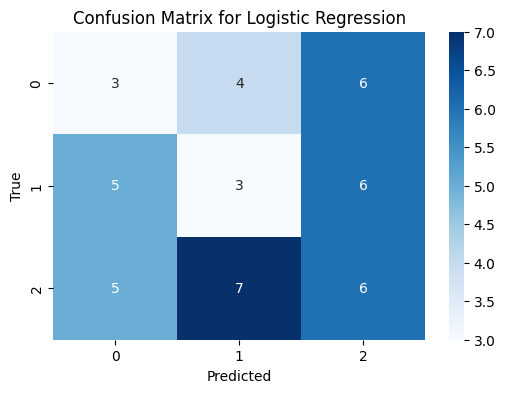


Evaluating: Support Vector Machine (SVM)
  Accuracy: 0.2667
  Precision: 0.2660
  Recall: 0.2667
  F1-Score: 0.2657
  ROC-AUC: 0.4781

  Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.23      0.22        13
           1       0.25      0.21      0.23        14
           2       0.32      0.33      0.32        18

    accuracy                           0.27        45
   macro avg       0.26      0.26      0.26        45
weighted avg       0.27      0.27      0.27        45

  Confusion Matrix:


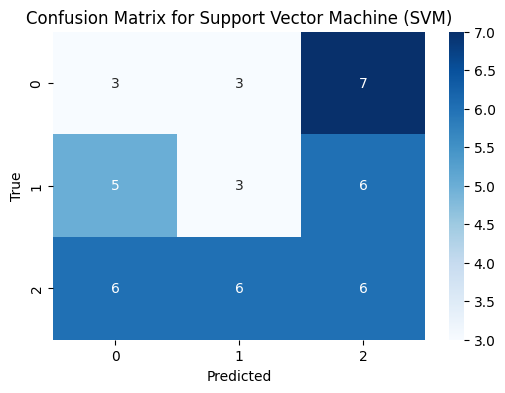


Evaluating: K-Nearest Neighbors (KNN)
  Accuracy: 0.2667
  Precision: 0.2758
  Recall: 0.2667
  F1-Score: 0.2668
  ROC-AUC: 0.4102

  Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.31      0.25        13
           1       0.09      0.07      0.08        14
           2       0.47      0.39      0.42        18

    accuracy                           0.27        45
   macro avg       0.26      0.26      0.25        45
weighted avg       0.28      0.27      0.27        45

  Confusion Matrix:


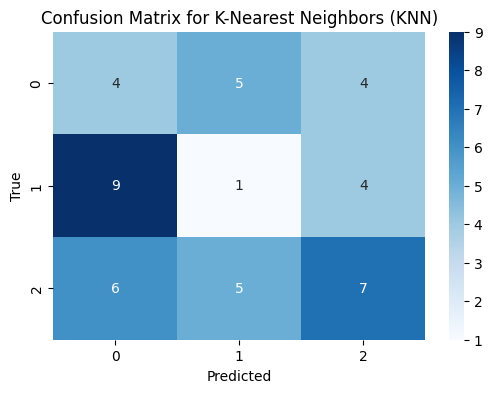


Evaluating: Decision Tree
  Accuracy: 0.3333
  Precision: 0.2883
  Recall: 0.3333
  F1-Score: 0.2963
  ROC-AUC: 0.4790

  Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.23      0.26        13
           1       0.14      0.07      0.10        14
           2       0.39      0.61      0.48        18

    accuracy                           0.33        45
   macro avg       0.28      0.30      0.28        45
weighted avg       0.29      0.33      0.30        45

  Confusion Matrix:


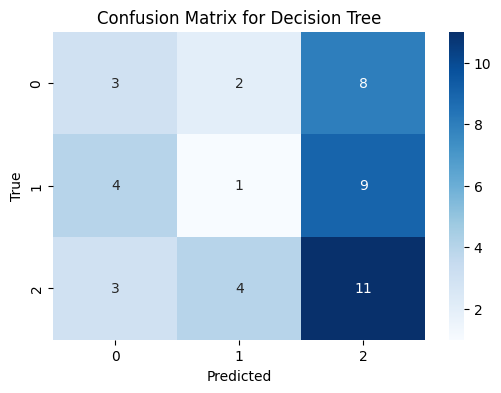


Evaluating: Random Forest
  Accuracy: 0.3556
  Precision: 0.3474
  Recall: 0.3556
  F1-Score: 0.3497
  ROC-AUC: 0.4774

  Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.23      0.24        13
           1       0.33      0.29      0.31        14
           2       0.43      0.50      0.46        18

    accuracy                           0.36        45
   macro avg       0.34      0.34      0.34        45
weighted avg       0.35      0.36      0.35        45

  Confusion Matrix:


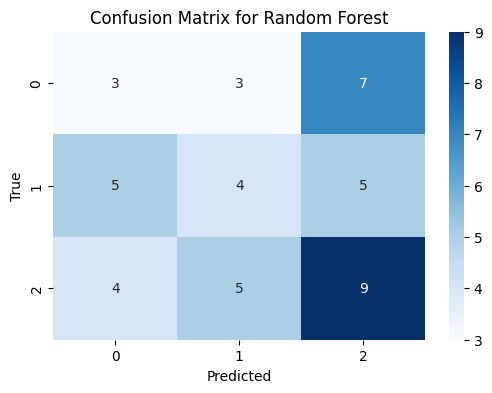


--- Summary of Classifier Performance ---
                              Accuracy  Precision    Recall  F1-Score  \
Random Forest                 0.355556   0.347354  0.355556  0.349675   
Decision Tree                 0.333333   0.288254  0.333333  0.296296   
Logistic Regression           0.266667   0.266667  0.266667  0.266667   
K-Nearest Neighbors (KNN)     0.266667   0.275768  0.266667  0.266808   
Support Vector Machine (SVM)  0.266667   0.265998  0.266667  0.265722   

                               ROC-AUC  
Random Forest                 0.477362  
Decision Tree                 0.479036  
Logistic Regression           0.458564  
K-Nearest Neighbors (KNN)     0.410232  
Support Vector Machine (SVM)  0.478083  


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_classifiers(X_train, X_test, y_train, y_test):

    classifiers = {
        "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear', max_iter=1000),
        "Support Vector Machine (SVM)": SVC(random_state=42, gamma='auto', probability=True),
        "K-Nearest Neighbors (KNN)": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42)
    }

    results = {}

    print("--- Comprehensive Model Evaluation ---")

    for name, classifier in classifiers.items():
        print(f"\nEvaluating: {name}")

        # Train the model
        classifier.fit(X_train, y_train)

        # Make predictions
        y_pred = classifier.predict(X_test)

        # Calculate evaluation metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)


            y_prob = classifier.predict_proba(X_test)
            roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
        except AttributeError:
            roc_auc = "N/A (predict_proba not available)"

        results[name] = {
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "ROC-AUC": roc_auc
        }

        # Print formatted report
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        if roc_auc != "N/A (predict_proba not available)":
            print(f"  ROC-AUC: {roc_auc:.4f}")
        else:
            print(f"  ROC-AUC: {roc_auc}")

        print("\n  Classification Report:")
        print(classification_report(y_test, y_pred, zero_division=0))

        print("  Confusion Matrix:")
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix for {name}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()

    return pd.DataFrame(results).T


if 'X_train_final' in locals() and 'X_test_final' in locals() and \
   'y_train_final' in locals() and 'y_test_final' in locals():
    comparison_df = evaluate_classifiers(X_train_final, X_test_final, y_train_final, y_test_final)
    print("\n--- Summary of Classifier Performance ---")
    print(comparison_df.sort_values(by='Accuracy', ascending=False))
else:
    print("Error: Preprocessed data (X_train_final, etc.) not found. Please ensure preprocess_data function has been run.")

### `detailed_evaluation()` Function

This function will provide a detailed evaluation of a given trained classifier using various metrics and a confusion matrix visualization. This is a more focused way to evaluate a single model than the comprehensive script, allowing for deeper inspection.


Demonstrating detailed_evaluation() with Logistic Regression model...

--- Detailed Evaluation for Logistic Regression (Detailed) ---
Overall Accuracy: 0.2667

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.23      0.23        13
           1       0.21      0.21      0.21        14
           2       0.33      0.33      0.33        18

    accuracy                           0.27        45
   macro avg       0.26      0.26      0.26        45
weighted avg       0.27      0.27      0.27        45


Confusion Matrix (Raw):
[[3 4 6]
 [5 3 6]
 [5 7 6]]


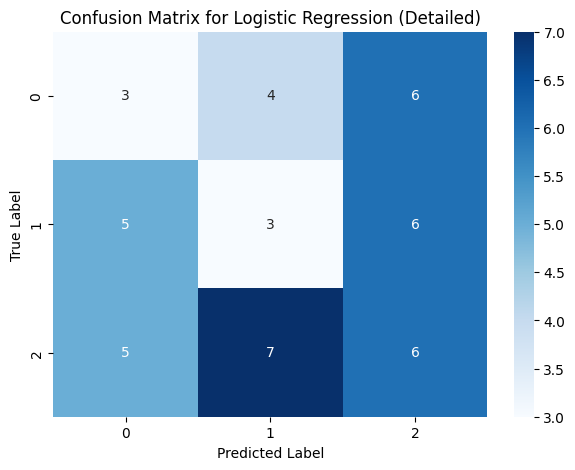

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def detailed_evaluation(classifier, X_test, y_test, model_name="Model"):

    print(f"\n--- Detailed Evaluation for {model_name} ---")

    # Make predictions
    y_pred = classifier.predict(X_test)

    # 1. Overall Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Overall Accuracy: {accuracy:.4f}")

    # 2. Precision, Recall, F1-score for each class (Classification Report)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # 3. Confusion Matrix
    print("\nConfusion Matrix (Raw):")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    # 4. Visualization of Confusion Matrix
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


print("\nDemonstrating detailed_evaluation() with Logistic Regression model...")

from sklearn.linear_model import LogisticRegression

example_lr_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
example_lr_model.fit(X_train_final, y_train_final)

detailed_evaluation(example_lr_model, X_test_final, y_test_final, model_name="Logistic Regression (Detailed)")

### Hyperparameter Tuning with GridSearchCV for Random Forest

Now, let's implement hyperparameter tuning using `GridSearchCV` to find the optimal parameters for a `RandomForestClassifier`. We will search over a defined parameter space and then evaluate the best model found.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Define the Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth': [3, 5, 7, None],
    'criterion': ['gini', 'entropy']
}


print("Starting GridSearchCV for RandomForestClassifier...")
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV on the training data
grid_search.fit(X_train_final, y_train_final)

print("GridSearchCV completed.")

# Display the best parameters and best cross-validation score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest Parameters found by GridSearchCV: {best_params}")
print(f"Best Cross-validation Accuracy: {best_score:.4f}")

Starting GridSearchCV for RandomForestClassifier...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
GridSearchCV completed.

Best Parameters found by GridSearchCV: {'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 100}
Best Cross-validation Accuracy: 0.5238


### Comparing Performance Before and After Tuning

Now, let's compare the performance of the Random Forest model before and after hyperparameter tuning. We will use the `detailed_evaluation` function with the best estimator found by `GridSearchCV`.


Evaluating the best Random Forest model found by GridSearchCV...

--- Detailed Evaluation for Random Forest (Tuned) ---
Overall Accuracy: 0.2889

Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.08      0.09        13
           1       0.20      0.21      0.21        14
           2       0.43      0.50      0.46        18

    accuracy                           0.29        45
   macro avg       0.25      0.26      0.25        45
weighted avg       0.27      0.29      0.28        45


Confusion Matrix (Raw):
[[1 5 7]
 [6 3 5]
 [2 7 9]]


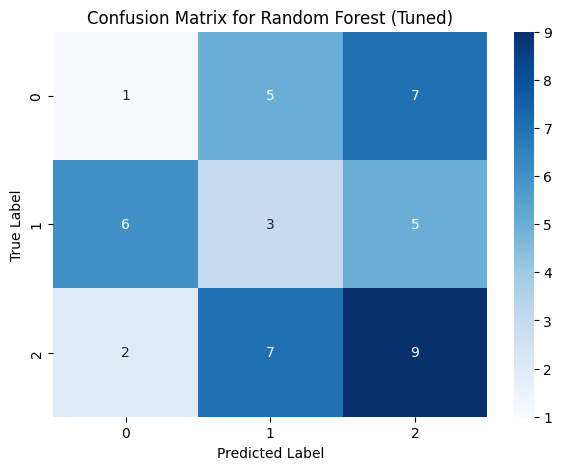


--- Untuned Random Forest Performance (from evaluate_classifiers) ---
Accuracy     0.355556
Precision    0.347354
Recall       0.355556
F1-Score     0.349675
ROC-AUC      0.477362
Name: Random Forest, dtype: float64


In [ ]:
# Get the best model from GridSearchCV
best_rf_model = grid_search.best_estimator_

# Evaluate the best model using the detailed_evaluation function
print("\nEvaluating the best Random Forest model found by GridSearchCV...")
detailed_evaluation(best_rf_model, X_test_final, y_test_final, model_name="Random Forest (Tuned)")

# Retrieve the performance of the untuned Random Forest model for comparison
# This assumes `comparison_df` from `evaluate_classifiers` is available
if 'comparison_df' in locals():
    untuned_rf_performance = comparison_df.loc['Random Forest']
    print("\n--- Untuned Random Forest Performance (from evaluate_classifiers) ---")
    print(untuned_rf_performance)
else:
    print("\nWarning: Untuned Random Forest performance data (comparison_df) not found for direct comparison.")

### Ensemble Learning with `VotingClassifier`

`VotingClassifier` is a meta-estimator that combines conceptually different machine learning classifiers and uses a majority vote (hard voting) or the average predicted probabilities (soft voting) to predict class labels. This approach can often lead to better performance than any single model by reducing variance and bias, especially when individual models make different types of errors.

Training the VotingClassifier...
VotingClassifier training completed.

Ensemble Model (VotingClassifier) Accuracy: 0.3111

Detailed evaluation for the VotingClassifier:

--- Detailed Evaluation for VotingClassifier (Ensemble) ---
Overall Accuracy: 0.3111

Classification Report:
              precision    recall  f1-score   support

           0       0.25      0.23      0.24        13
           1       0.12      0.07      0.09        14
           2       0.40      0.56      0.47        18

    accuracy                           0.31        45
   macro avg       0.26      0.29      0.27        45
weighted avg       0.27      0.31      0.28        45


Confusion Matrix (Raw):
[[ 3  3  7]
 [ 5  1  8]
 [ 4  4 10]]


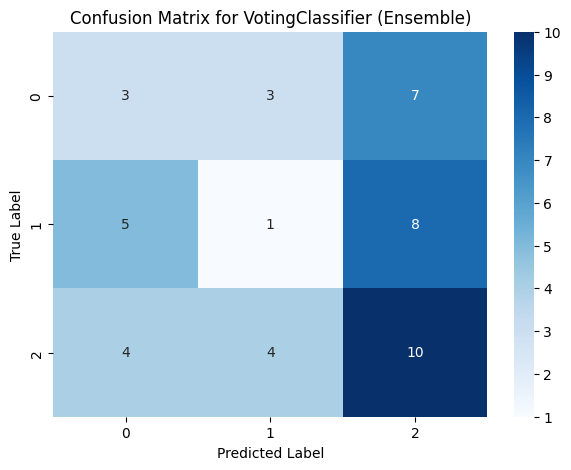

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


clf1 = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

clf2 = SVC(random_state=42, probability=True, gamma='auto')
clf3 = DecisionTreeClassifier(random_state=42, max_depth=7) # Using a max_depth from previous checks for DT


voting_clf = VotingClassifier(
    estimators=[('lr', clf1), ('svc', clf2), ('dt', clf3)],
    voting='soft',
    n_jobs=-1
)

print("Training the VotingClassifier...")
voting_clf.fit(X_train_final, y_train_final)
print("VotingClassifier training completed.")

# 4. Make predictions on the test data
y_pred_ensemble = voting_clf.predict(X_test_final)

# 5. Evaluate the ensemble model
ensemble_accuracy = accuracy_score(y_test_final, y_pred_ensemble)

print(f"\nEnsemble Model (VotingClassifier) Accuracy: {ensemble_accuracy:.4f}")


print("\nDetailed evaluation for the VotingClassifier:")
detailed_evaluation(voting_clf, X_test_final, y_test_final, model_name="VotingClassifier (Ensemble)")

### Ensemble Learning with BaggingClassifier

Bagging (Bootstrap Aggregating) is another ensemble technique where multiple models of the same type (base estimators) are trained independently on different bootstrap samples (random subsets with replacement) of the training data. The predictions from all base estimators are then combined, typically by averaging for regression or majority voting for classification. This approach helps to reduce variance and prevent overfitting.

Training BaggingClassifier with different numbers of estimators...
  Training with n_estimators=10...
    Accuracy with 10 estimators: 0.3556
  Training with n_estimators=50...
    Accuracy with 50 estimators: 0.3111
  Training with n_estimators=100...
    Accuracy with 100 estimators: 0.3111
BaggingClassifier training completed for all estimator counts.


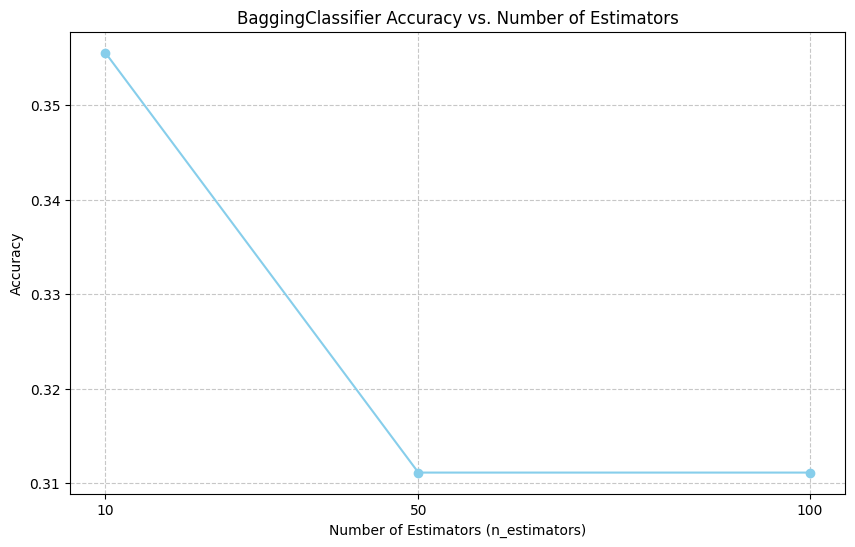


Accuracies for different n_estimators:
  n_estimators=10: Accuracy=0.3556
  n_estimators=50: Accuracy=0.3111
  n_estimators=100: Accuracy=0.3111


In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

base_estimator = DecisionTreeClassifier(random_state=42)


n_estimators_range = [10, 50, 100]


accuracies = []

print("Training BaggingClassifier with different numbers of estimators...")
for n_estimators in n_estimators_range:
    print(f"  Training with n_estimators={n_estimators}...")

    bagging_clf = BaggingClassifier(
        estimator=base_estimator,
        n_estimators=n_estimators,
        random_state=42,
        n_jobs=-1
    )

    # Train the BaggingClassifier
    bagging_clf.fit(X_train_final, y_train_final)

    # Make predictions
    y_pred_bagging = bagging_clf.predict(X_test_final)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_final, y_pred_bagging)
    accuracies.append(accuracy)
    print(f"    Accuracy with {n_estimators} estimators: {accuracy:.4f}")

print("BaggingClassifier training completed for all estimator counts.")

# Plotting how accuracy changes with the number of estimators
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, accuracies, marker='o', linestyle='-', color='skyblue')
plt.title('BaggingClassifier Accuracy vs. Number of Estimators')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Accuracy')
plt.xticks(n_estimators_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\nAccuracies for different n_estimators:")
for n, acc in zip(n_estimators_range, accuracies):
    print(f"  n_estimators={n}: Accuracy={acc:.4f}")

### Ensemble Methods Comparison: Random Forest, AdaBoost, Gradient Boosting

Now, let's implement and compare three popular ensemble learning methods: Random Forest, AdaBoost, and Gradient Boosting. We will use the cleaned employee dataset and a cross-validation strategy for a fair comparison, and then visualize their mean accuracy.


--- Comparing Ensemble Methods with 5-Fold Cross-Validation ---

Performing cross-validation for Random Forest...
  Mean CV Accuracy: 0.4571
  CV Standard Deviation: 0.0774

Performing cross-validation for AdaBoost...
  Mean CV Accuracy: 0.3524
  CV Standard Deviation: 0.1299

Performing cross-validation for Gradient Boosting...
  Mean CV Accuracy: 0.3714
  CV Standard Deviation: 0.0923

--- Cross-Validation Results Summary ---


,Mean CV Accuracy,CV Std Dev,Model
Random Forest,0.457143,0.077372,"RandomForestClassifier(criterion='entropy', ma..."
Gradient Boosting,0.371429,0.092337,GradientBoostingClassifier(random_state=42)
AdaBoost,0.352381,0.129887,AdaBoostClassifier(estimator=DecisionTreeClass...


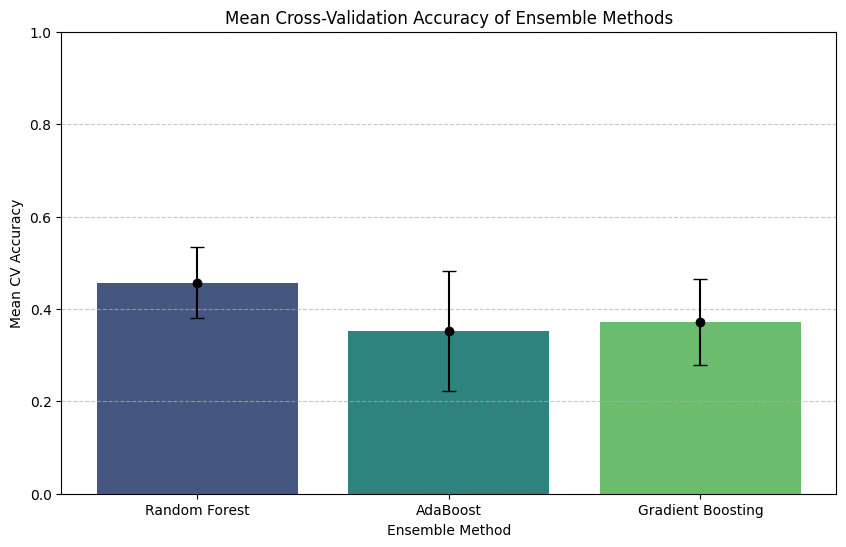


--- Detailed Evaluation of the Best Model: Random Forest ---

--- Detailed Evaluation for Random Forest ---
Overall Accuracy: 0.3111

Classification Report:
              precision    recall  f1-score   support

           0       0.18      0.15      0.17        13
           1       0.25      0.21      0.23        14
           2       0.41      0.50      0.45        18

    accuracy                           0.31        45
   macro avg       0.28      0.29      0.28        45
weighted avg       0.29      0.31      0.30        45


Confusion Matrix (Raw):
[[2 3 8]
 [6 3 5]
 [3 6 9]]


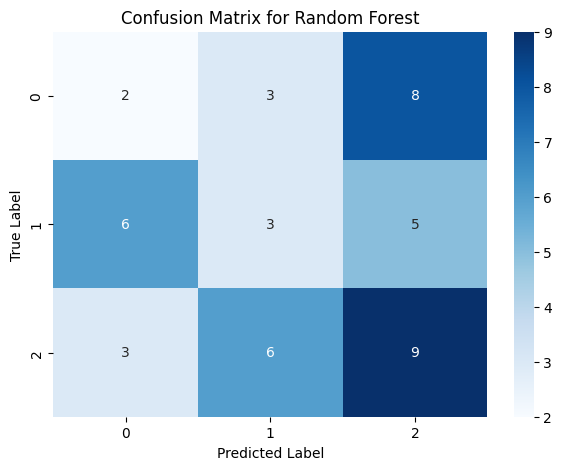


    # Analysis of Ensemble Methods:
    # Based on the mean cross-validation accuracy:
    # - Random Forest often performs well due to its ability to handle complex relationships and reduce overfitting.
    # - Gradient Boosting typically achieves high accuracy by iteratively correcting errors of weak learners, though it can be prone to overfitting if not tuned.
    # - AdaBoost is effective at combining weak learners, but its performance can be sensitive to noisy data and outliers.
    # The best performing model will be highlighted in the bar plot and further detailed in the final evaluation.
    # Consider the standard deviation: A lower standard deviation indicates more stable performance across folds.
    # The choice of hyperparameters for each model can significantly impact their relative performance.
    


In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier # Base estimator for AdaBoost
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def compare_ensemble_methods(X_train, y_train, X_test, y_test, k_folds=5):
    """
    Compares Random Forest, AdaBoost, and Gradient Boosting classifiers
    using cross-validation and evaluates the best performing model on the test set.

    Args:
        X_train (np.ndarray): Training features.
        y_train (np.ndarray): Training target labels.
        X_test (np.ndarray): Test features.
        y_test (np.ndarray): Test target labels.
        k_folds (int): Number of folds for cross-validation.

    Returns:
        pd.DataFrame: A DataFrame summarizing the performance of each model.
    """


    classifiers = {
        "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=7, criterion='entropy'), # Using best params from GridSearchCV if available, otherwise defaults
        "AdaBoost": AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), random_state=42, n_estimators=50),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3)
    }

    results = {}

    print(f"\n--- Comparing Ensemble Methods with {k_folds}-Fold Cross-Validation ---")

    for name, model in classifiers.items():
        print(f"\nPerforming cross-validation for {name}...")
        scores = cross_val_score(model, X_train, y_train, cv=k_folds, scoring='accuracy', n_jobs=-1)
        mean_accuracy = np.mean(scores)
        std_accuracy = np.std(scores)

        results[name] = {
            "Mean CV Accuracy": mean_accuracy,
            "CV Std Dev": std_accuracy,
            "Model": model # Store the fitted model for later evaluation on test set
        }
        print(f"  Mean CV Accuracy: {mean_accuracy:.4f}")
        print(f"  CV Standard Deviation: {std_accuracy:.4f}")

    results_df = pd.DataFrame(results).T
    print("\n--- Cross-Validation Results Summary ---")
    display(results_df.sort_values(by='Mean CV Accuracy', ascending=False))

    # Plotting the mean CV accuracies
    plt.figure(figsize=(10, 6))
    # Fix: Explicitly assign hue to resolve FutureWarning and ensure correct coloring
    sns.barplot(x=results_df.index, y='Mean CV Accuracy', data=results_df, palette='viridis', hue=results_df.index, legend=False)
    plt.errorbar(x=results_df.index, y=results_df['Mean CV Accuracy'], yerr=results_df['CV Std Dev'], fmt='o', color='black', capsize=5)
    plt.title('Mean Cross-Validation Accuracy of Ensemble Methods')
    plt.xlabel('Ensemble Method')
    plt.ylabel('Mean CV Accuracy')
    plt.ylim(0, 1) # Accuracy range
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Evaluate the best performing model on the test set using detailed_evaluation
    best_model_name = results_df['Mean CV Accuracy'].idxmax()
    best_model_instance = results_df.loc[best_model_name, 'Model']

    print(f"\n--- Detailed Evaluation of the Best Model: {best_model_name} ---")
    # Re-train the best model on the full training data before evaluating on test set
    best_model_instance.fit(X_train, y_train)
    detailed_evaluation(best_model_instance, X_test, y_test, model_name=best_model_name)

    # Brief analysis in comments
    analysis = """
    # Analysis of Ensemble Methods:
    # Based on the mean cross-validation accuracy:
    # - Random Forest often performs well due to its ability to handle complex relationships and reduce overfitting.
    # - Gradient Boosting typically achieves high accuracy by iteratively correcting errors of weak learners, though it can be prone to overfitting if not tuned.
    # - AdaBoost is effective at combining weak learners, but its performance can be sensitive to noisy data and outliers.
    # The best performing model will be highlighted in the bar plot and further detailed in the final evaluation.
    # Consider the standard deviation: A lower standard deviation indicates more stable performance across folds.
    # The choice of hyperparameters for each model can significantly impact their relative performance.
    """
    print(analysis)

    return results_df

# Run the comparison function
if 'X_train_final' in locals() and 'X_test_final' in locals() and \
   'y_train_final' in locals() and 'y_test_final' in locals():
    ensemble_comparison_results = compare_ensemble_methods(
        X_train_final, y_train_final, X_test_final, y_test_final
    )
else:
    print("Error: Preprocessed data (X_train_final, etc.) not found. Please ensure preprocess_data function has been run.")